# Model 1A, Experiment 01: Raw Logistic-Regression Baseline

This notebook rebuilds the first-pass grid-searched logistic regression for flights departing JFK. The target, `DepDel15`, equals 1 when departure delay is at least 15 minutes and 0 otherwise.

Experiment 01 intentionally uses a compact set of **raw, pre-pushback** schedule, flight-identity, planned-demand, and weather fields. It updates the first-pass exploratory baseline in several methodological respects:

- input comes from the shared feature dataset, while the model allowlist still selects raw columns only;
- complete calendar days are kept together;
- grid search uses expanding-window day folds within 2019;
- the selected pipeline is refitted on all 2019 flights and evaluated on 2023;
- missing values are imputed inside the pipeline;
- optional L1 model-based feature selection is fitted inside each training fold and competes with passthrough;
- performance includes average precision, ROC AUC, MCC, Brier score, calibration, and a training-only threshold comparison.

The 2023 labels are used only for the external validation reported after all model and threshold choices are fixed. The 2024 dataset is not loaded. Engineered Appendix C predictors belong in Experiment 02.

In [1]:
# Parameters
AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "DepDel15"

RANDOM_STATE = 42
N_TIME_SPLITS = 5
N_JOBS = 4


In [2]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    make_scorer,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


## Load and validate the shared 2019 and 2023 departure feature data

The path lookup supports running from either the project root or the `models` directory. Although the source contains Appendix C engineered columns, the explicit Experiment 01 allowlist below admits only raw fields.

In [3]:
def find_project_root(start: Path, airport: str, years) -> Path:
    """Return the nearest parent containing every requested feature file."""
    relative_paths = [
        Path("data/features") / f"{airport}_{year}_departures.csv"
        for year in years
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).exists() for path in relative_paths):
            return candidate
    raise FileNotFoundError(f"Could not locate all required files: {relative_paths}")


PROJECT_ROOT = find_project_root(
    Path.cwd().resolve(),
    AIRPORT,
    [TRAIN_YEAR, VALIDATION_YEAR],
)
TRAIN_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{TRAIN_YEAR}_departures.csv"
VALIDATION_DATA_PATH = (
    PROJECT_ROOT / "data/features" / f"{AIRPORT}_{VALIDATION_YEAR}_departures.csv"
)

train_df = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)
validation_df = pd.read_csv(VALIDATION_DATA_PATH, low_memory=False)

print(f"Training source: {TRAIN_DATA_PATH}")
print(f"Training rows: {len(train_df):,}; columns: {train_df.shape[1]:,}")
print(f"Validation source: {VALIDATION_DATA_PATH}")
print(f"Validation rows: {len(validation_df):,}; columns: {validation_df.shape[1]:,}")


Training source: /Users/johnkyte/Projects/berkeley_ml_and_ai/capstone/data/features/JFK_2019_departures.csv
Training rows: 107,430; columns: 112
Validation source: /Users/johnkyte/Projects/berkeley_ml_and_ai/capstone/data/features/JFK_2023_departures.csv
Validation rows: 109,983; columns: 112


In [4]:
def validate_source_frame(frame: pd.DataFrame, year: int, partition: str):
    """Validate one source population and return its audit summary."""
    required_audit_columns = {"FlightDate", "Origin", TARGET}
    missing_audit_columns = sorted(required_audit_columns - set(frame.columns))
    assert not missing_audit_columns, f"{partition} missing audit columns: {missing_audit_columns}"

    frame["FlightDate"] = pd.to_datetime(frame["FlightDate"], errors="coerce")
    assert frame["FlightDate"].notna().all(), f"{partition} has invalid FlightDate values"
    assert frame["FlightDate"].dt.year.eq(year).all(), f"{partition} has rows outside {year}"
    assert frame["Origin"].eq(AIRPORT).all(), f"{partition} Origin must equal {AIRPORT}"
    assert frame[TARGET].notna().all(), f"{partition} {TARGET} contains missing values"
    assert set(frame[TARGET].unique()).issubset({0, 0.0, 1, 1.0}), (
        f"{partition} has unexpected {TARGET} values"
    )

    return {
        "partition": partition,
        "year": year,
        "start": frame["FlightDate"].min().date(),
        "end": frame["FlightDate"].max().date(),
        "days": frame["FlightDate"].dt.normalize().nunique(),
        "rows": len(frame),
        "delayed_flights": int(frame[TARGET].sum()),
        "delay_rate": frame[TARGET].mean(),
    }


source_summary = pd.DataFrame(
    [
        validate_source_frame(train_df, TRAIN_YEAR, "training"),
        validate_source_frame(validation_df, VALIDATION_YEAR, "external validation"),
    ]
).set_index("partition")
source_summary


,year,start,end,days,rows,delayed_flights,delay_rate
partition,,,,,,,
training,2019,2019-01-01,2019-12-31,365,107430,20168,0.1877
external validation,2023,2023-01-01,2023-12-31,365,109983,25995,0.2364


## Raw prediction-time feature manifest

The allowlist repeats the first-pass feature groups:

1. **Calendar and schedule:** month, weekday, scheduled departure/arrival HHMM, scheduled elapsed time, and distance.
2. **Flight identity:** reporting airline and destination.
3. **Planned airport demand:** scheduled arrivals and departures in the previous, current, and next clock hours.
4. **Causally available weather:** the most recent raw temperature, precipitation, humidity, visibility, and wind-speed measurements available by scheduled departure.

This experiment deliberately retains raw HHMM fields so that Experiment 02 can measure the incremental value of cyclical and other engineered representations. Actual departure, taxi, takeoff, arrival outcomes, audit timestamps, and engineered columns are excluded.

In [5]:
# Month and weekday are categorical because their numeric spacing is not a linear effect.
categorical_features = [
    "Month",
    "DayOfWeek",
    "Reporting_Airline",
    "Dest",
]

numeric_features = [
    "CRSDepTime",
    "CRSArrTime",
    "CRSElapsedTime",
    "Distance",
    "ASPM_PREVIOUS_SCHEDULED_DEPARTURES",
    "ASPM_PREVIOUS_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_SCHEDULED_DEPARTURES",
    "ASPM_CURRENT_SCHEDULED_ARRIVALS",
    "ASPM_NEXT_SCHEDULED_DEPARTURES",
    "ASPM_NEXT_SCHEDULED_ARRIVALS",
    "HourlyDewPointTemperature",
    "HourlyDryBulbTemperature",
    "HourlyPrecipitation",
    "HourlyRelativeHumidity",
    "HourlyVisibility",
    "HourlyWindSpeed",
]

feature_columns = categorical_features + numeric_features
required_columns = ["FlightDate", "Origin", TARGET, *feature_columns]
for partition, frame in [("training", train_df), ("external validation", validation_df)]:
    missing_columns = sorted(set(required_columns) - set(frame.columns))
    assert not missing_columns, f"{partition} missing required columns: {missing_columns}"

forbidden_predictors = {
    TARGET,
    "DepTime",
    "DepDelay",
    "DepDelayMinutes",
    "DepartureDelayGroups",
    "TaxiOut",
    "WheelsOff",
    "ArrDel15",
    "ArrivalDelayGroups",
    "Tail_Number",
}
leaking_columns = sorted(forbidden_predictors.intersection(feature_columns))
assert not leaking_columns, f"Prediction-time-invalid features selected: {leaking_columns}"

engineered_prefixes = (
    "SCHED_",
    "LOG_",
    "ASPM_THREE_",
    "ACTUAL_",
)
unexpected_engineered = [
    column for column in feature_columns
    if column.startswith(engineered_prefixes)
]
assert not unexpected_engineered, f"Experiment 01 must remain raw: {unexpected_engineered}"

print(f"Selected {len(feature_columns)} raw source predictors")
print(f"  categorical: {len(categorical_features)}")
print(f"  numeric: {len(numeric_features)}")


Selected 20 raw source predictors
  categorical: 4
  numeric: 16


## Missingness and temporal partitions

All 2019 rows form the training dataset. Its calendar days are divided into six consecutive blocks; five expanding-window folds train on all earlier blocks and validate on the next block. After selection, grid search refits the winning pipeline on all 2019 rows. The separately loaded 2023 rows are evaluated only after that refit.

No row is dropped for a missing predictor. Categorical mode imputation and numeric median imputation are learned separately inside every training fold. Numeric missingness indicators are added only when a training fold contains a missing value.

In [6]:
def prepare_model_frame(source_frame: pd.DataFrame) -> pd.DataFrame:
    """Select columns, sort chronologically, and normalize input dtypes."""
    model_frame = source_frame[required_columns].copy()
    model_frame = model_frame.sort_values(
        ["FlightDate", "CRSDepTime"],
        kind="stable",
    ).reset_index(drop=True)
    model_frame[TARGET] = model_frame[TARGET].astype(int)

    for column in categorical_features:
        model_frame[column] = model_frame[column].astype(object)
    for column in numeric_features:
        model_frame[column] = pd.to_numeric(model_frame[column], errors="coerce")

    return model_frame


train_model_df = prepare_model_frame(train_df)
validation_model_df = prepare_model_frame(validation_df)

missing_summary = pd.DataFrame(
    {
        "training_missing": train_model_df[feature_columns].isna().sum(),
        "validation_missing": validation_model_df[feature_columns].isna().sum(),
    }
)
display(missing_summary[missing_summary.sum(axis=1).gt(0)])

X_train = train_model_df[feature_columns].reset_index(drop=True)
y_train = train_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)

X_validation = validation_model_df[feature_columns].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)

assert training_dates.max() < validation_dates.min()


,training_missing,validation_missing
ASPM_NEXT_SCHEDULED_DEPARTURES,1,0
ASPM_NEXT_SCHEDULED_ARRIVALS,1,0
HourlyDewPointTemperature,46,0
HourlyPrecipitation,22,21
HourlyVisibility,0,28


In [7]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    """Create expanding train/validation indices without splitting calendar days."""
    normalized_dates = dates.dt.normalize().to_numpy()
    unique_days = np.array(sorted(pd.unique(normalized_dates)))

    if len(unique_days) < n_splits + 1:
        raise ValueError("Not enough unique days for the requested temporal folds")

    day_blocks = np.array_split(unique_days, n_splits + 1)
    splits = []
    rows = []

    for fold_number in range(1, n_splits + 1):
        train_days = np.concatenate(day_blocks[:fold_number])
        validation_days = day_blocks[fold_number]
        train_indices = np.flatnonzero(np.isin(normalized_dates, train_days))
        validation_indices = np.flatnonzero(np.isin(normalized_dates, validation_days))

        assert train_indices.size and validation_indices.size
        assert train_days.max() < validation_days.min()
        splits.append((train_indices, validation_indices))
        rows.append(
            {
                "fold": fold_number,
                "train_start": pd.Timestamp(train_days.min()).date(),
                "train_end": pd.Timestamp(train_days.max()).date(),
                "validation_start": pd.Timestamp(validation_days.min()).date(),
                "validation_end": pd.Timestamp(validation_days.max()).date(),
                "train_rows": len(train_indices),
                "validation_rows": len(validation_indices),
                "train_delay_rate": targets.iloc[train_indices].mean(),
                "validation_delay_rate": targets.iloc[validation_indices].mean(),
            }
        )

    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(
    training_dates,
    y_train,
    N_TIME_SPLITS,
)

partition_summary = pd.DataFrame(
    {
        "start": [training_dates.min().date(), validation_dates.min().date()],
        "end": [training_dates.max().date(), validation_dates.max().date()],
        "days": [
            training_dates.dt.normalize().nunique(),
            validation_dates.dt.normalize().nunique(),
        ],
        "rows": [len(y_train), len(y_validation)],
        "delayed_flights": [y_train.sum(), y_validation.sum()],
        "delay_rate": [y_train.mean(), y_validation.mean()],
    },
    index=["2019 training", "2023 external validation"],
)

display(partition_summary)
fold_summary


,start,end,days,rows,delayed_flights,delay_rate
2019 training,2019-01-01,2019-12-31,365,107430,20168,0.1877
2023 external validation,2023-01-01,2023-12-31,365,109983,25995,0.2364


,train_start,train_end,validation_start,validation_end,train_rows,validation_rows,train_delay_rate,validation_delay_rate
fold,,,,,,,,
1,2019-01-01,2019-03-02,2019-03-03,2019-05-02,17737,18776,0.1892,0.1674
2,2019-01-01,2019-05-02,2019-05-03,2019-07-02,36513,18150,0.1780,0.2072
3,2019-01-01,2019-07-02,2019-07-03,2019-09-01,54663,17758,0.1877,0.2577
4,2019-01-01,2019-09-01,2019-09-02,2019-11-01,72421,17686,0.2048,0.1384
5,2019-01-01,2019-11-01,2019-11-02,2019-12-31,90107,17323,0.1918,0.1666


## Preprocessing, feature selection, and logistic regression

The preprocessing and optional selection steps are part of one scikit-learn `Pipeline`, so every statistic and selected feature is learned from the training portion of each temporal fold.

The grid compares:

- **passthrough:** all encoded raw features reach the final regularized classifier;
- **L1 `SelectFromModel`:** a separate L1 logistic model removes weak encoded columns using either the mean or 1.5 times the mean absolute coefficient.

Separate feature selection is not assumed to help. Regularized logistic regression already controls coefficient magnitude, so passthrough remains a first-class candidate. The selected configuration must earn its place through mean temporal-validation average precision.

In [8]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_pipeline, categorical_features),
        ("numeric", numeric_pipeline, numeric_features),
    ],
    remainder="drop",
)

l1_selector = SelectFromModel(
    estimator=LogisticRegression(
        C=0.1,
        l1_ratio=1.0,
        solver="liblinear",
        class_weight=None,
        max_iter=5_000,
        random_state=RANDOM_STATE,
    ),
    threshold="mean",
)

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("feature_selection", "passthrough"),
        (
            "classifier",
            LogisticRegression(
                solver="liblinear",
                max_iter=5_000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# A list of grids permits selector-only parameters without applying them to passthrough.
parameter_grid = [
    {
        "feature_selection": ["passthrough"],
        "classifier__C": [0.01, 0.1, 1.0, 10.0],
        "classifier__l1_ratio": [1.0, 0.0],
        "classifier__class_weight": [None, "balanced"],
    },
    {
        "feature_selection": [l1_selector],
        "feature_selection__threshold": ["mean", "1.5*mean"],
        "classifier__C": [0.01, 0.1, 1.0, 10.0],
        "classifier__l1_ratio": [0.0],
        "classifier__class_weight": [None, "balanced"],
    },
]

scoring = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": "recall",
    "f1": "f1",
    "mcc": make_scorer(matthews_corrcoef),
    "neg_brier": "neg_brier_score",
}

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=parameter_grid,
    scoring=scoring,
    refit="average_precision",
    cv=temporal_splits,
    n_jobs=N_JOBS,
    pre_dispatch=N_JOBS,
    verbose=1,
    return_train_score=False,
    error_score="raise",
)

parameter_count = sum(len(list(ParameterGrid(grid))) for grid in parameter_grid)
print(f"Hyperparameter combinations: {parameter_count:,}")
print(f"Temporal cross-validation fits: {parameter_count * len(temporal_splits):,}")


Hyperparameter combinations: 32
Temporal cross-validation fits: 160


In [9]:
search_start = perf_counter()
grid_search.fit(X_train, y_train)
search_seconds = perf_counter() - search_start

best_logistic_pipeline = grid_search.best_estimator_

print(f"Grid search and refit completed in {search_seconds:,.1f} seconds")
print(f"Best mean temporal-validation average precision: {grid_search.best_score_:.4f}")
print("Best parameters:")
display(pd.Series(grid_search.best_params_, name="value").to_frame())


Fitting 5 folds for each of 32 candidates, totalling 160 fits


/Users/johnkyte/Projects/berkeley_ml_and_ai/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Grid search and refit completed in 97.0 seconds
Best mean temporal-validation average precision: 0.3068
Best parameters:


,value
classifier__C,10.0000
classifier__class_weight,None
classifier__l1_ratio,1.0000
feature_selection,passthrough


In [10]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results["feature_selection_strategy"] = cv_results["param_feature_selection"].map(
    lambda value: "passthrough" if value == "passthrough" else "L1 SelectFromModel"
)
cv_results["classifier_penalty"] = cv_results["param_classifier__l1_ratio"].map(
    {1.0: "l1", 0.0: "l2"}
)
if "param_feature_selection__threshold" not in cv_results.columns:
    cv_results["param_feature_selection__threshold"] = np.nan

result_columns = [
    "rank_test_average_precision",
    "mean_test_average_precision",
    "std_test_average_precision",
    "mean_test_roc_auc",
    "mean_test_balanced_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_mcc",
    "mean_test_neg_brier",
    "feature_selection_strategy",
    "param_feature_selection__threshold",
    "param_classifier__C",
    "classifier_penalty",
    "param_classifier__class_weight",
]

display(
    cv_results.sort_values("rank_test_average_precision")[result_columns].head(12)
)

selection_comparison = (
    cv_results.groupby("feature_selection_strategy")
    .agg(
        best_mean_average_precision=("mean_test_average_precision", "max"),
        best_mean_roc_auc=("mean_test_roc_auc", "max"),
        best_mean_neg_brier=("mean_test_neg_brier", "max"),
        candidates=("mean_test_average_precision", "size"),
    )
    .sort_values("best_mean_average_precision", ascending=False)
)
selection_comparison


,rank_test_average_precision,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,mean_test_balanced_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_mcc,mean_test_neg_brier,feature_selection_strategy,param_feature_selection__threshold,param_classifier__C,classifier_penalty,param_classifier__class_weight
12,1,0.3068,0.0628,0.6621,0.5219,0.4568,0.0642,0.0986,0.0955,-0.1506,passthrough,NaN,10.0000,l1,NaN
0,2,0.3064,0.0595,0.6633,0.5037,0.5221,0.0091,0.0178,0.0455,-0.1469,passthrough,NaN,0.0100,l1,NaN
1,3,0.3044,0.0615,0.6617,0.5101,0.4786,0.0273,0.0505,0.0728,-0.1482,passthrough,NaN,0.0100,l2,NaN
5,4,0.3017,0.0638,0.6578,0.5143,0.4707,0.0419,0.0713,0.0818,-0.1497,passthrough,NaN,0.1000,l2,NaN
4,5,0.3017,0.0552,0.6600,0.5087,0.4832,0.0261,0.0454,0.0629,-0.1500,passthrough,NaN,0.1000,l1,NaN
13,6,0.3012,0.0651,0.6566,0.5156,0.4545,0.0474,0.0776,0.0822,-0.1501,passthrough,NaN,10.0000,l2,NaN
9,7,0.3007,0.0649,0.6561,0.5153,0.4554,0.0462,0.0760,0.0817,-0.1501,passthrough,NaN,1.0000,l2,NaN
2,8,0.2993,0.0618,0.6595,0.6033,0.2835,0.5160,0.3465,0.1706,-0.2108,passthrough,NaN,0.0100,l1,balanced
8,9,0.2993,0.0544,0.6569,0.5139,0.4798,0.0428,0.0663,0.0749,-0.1514,passthrough,NaN,1.0000,l1,NaN
17,10,0.2982,0.0550,0.6606,0.5040,0.5039,0.0108,0.0202,0.0387,-0.1496,L1 SelectFromModel,1.5*mean,0.0100,l2,NaN


,best_mean_average_precision,best_mean_roc_auc,best_mean_neg_brier,candidates
feature_selection_strategy,,,,
passthrough,0.3068,0.6633,-0.1469,16
L1 SelectFromModel,0.2982,0.6607,-0.1496,16


In [11]:
encoded_feature_names = best_logistic_pipeline.named_steps["preprocessor"].get_feature_names_out()
selection_step = best_logistic_pipeline.named_steps["feature_selection"]

if selection_step == "passthrough":
    selected_mask = np.ones(len(encoded_feature_names), dtype=bool)
    selected_strategy = "passthrough"
else:
    selected_mask = selection_step.get_support()
    selected_strategy = (
        f"L1 SelectFromModel "
        f"(threshold={grid_search.best_params_['feature_selection__threshold']})"
    )

selected_feature_names = encoded_feature_names[selected_mask]

feature_selection_summary = pd.Series(
    {
        "strategy": selected_strategy,
        "encoded_features_before_selection": len(encoded_feature_names),
        "features_after_selection": len(selected_feature_names),
        "features_removed": len(encoded_feature_names) - len(selected_feature_names),
    },
    name="value",
)
feature_selection_summary.to_frame()


,value
strategy,passthrough
encoded_features_before_selection,99
features_after_selection,99
features_removed,0


## Select a classification threshold using 2019 only

Average precision and ROC AUC evaluate probability ranking, but operational labels require a threshold. The best pipeline is cloned and refitted once per temporal fold. Each validation row receives a probability from a model trained only on earlier days.

Thresholds from 0.05 through 0.50 are compared on these out-of-fold temporal predictions. The threshold with the highest F1 is selected, with balanced accuracy and then precision used only as tie-breakers. No 2023 label is used for threshold selection.

Threshold-selection rows: 89,693
Training-only selected threshold: 0.17


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc
12,0.1700,0.5710,0.5990,0.2499,0.6437,0.3600,0.1546
10,0.1500,0.5305,0.5966,0.2414,0.7024,0.3593,0.1514
11,0.1600,0.5514,0.5974,0.2453,0.6709,0.3592,0.1520
9,0.1400,0.5080,0.5947,0.2372,0.7335,0.3585,0.1498
13,0.1800,0.5892,0.5973,0.2530,0.6103,0.3577,0.1526
8,0.1300,0.4825,0.5912,0.2325,0.7652,0.3566,0.1464
14,0.1900,0.6051,0.5952,0.2557,0.5792,0.3548,0.1503
7,0.1200,0.4559,0.5875,0.2281,0.7981,0.3548,0.1437
15,0.2000,0.6204,0.5933,0.2588,0.5500,0.3519,0.1487
6,0.1100,0.4267,0.5819,0.2232,0.8301,0.3518,0.1390


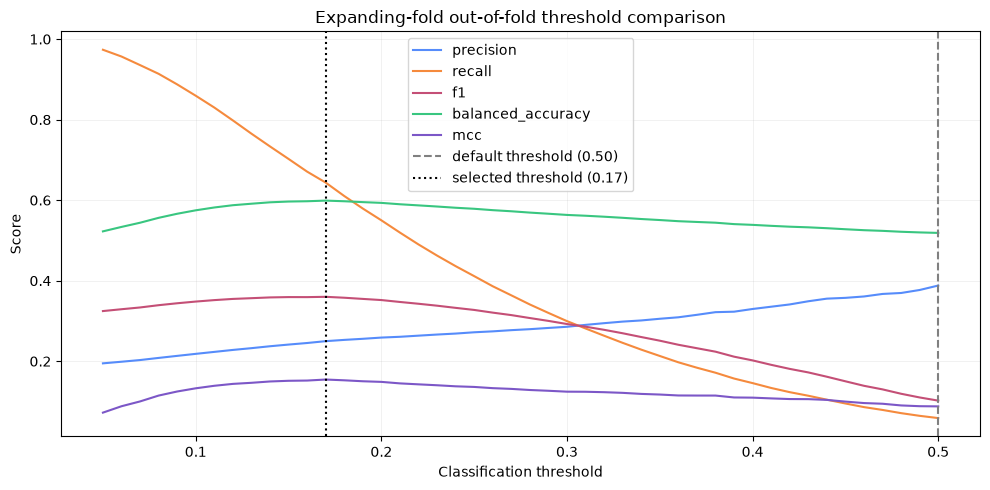

In [12]:
oof_probabilities = np.full(len(y_train), np.nan)

for train_indices, validation_indices in temporal_splits:
    fold_model = clone(best_logistic_pipeline)
    fold_model.fit(
        X_train.iloc[train_indices],
        y_train.iloc[train_indices],
    )
    oof_probabilities[validation_indices] = fold_model.predict_proba(
        X_train.iloc[validation_indices]
    )[:, 1]

oof_mask = np.isfinite(oof_probabilities)
assert oof_mask.sum() > 0
assert np.isfinite(oof_probabilities[oof_mask]).all()

candidate_thresholds = np.round(np.arange(0.05, 0.501, 0.01), 2)
threshold_rows = []
oof_y = y_train.to_numpy()[oof_mask]
oof_p = oof_probabilities[oof_mask]

for threshold in candidate_thresholds:
    predictions = (oof_p >= threshold).astype(int)
    threshold_rows.append(
        {
            "threshold": threshold,
            "accuracy": accuracy_score(oof_y, predictions),
            "balanced_accuracy": balanced_accuracy_score(oof_y, predictions),
            "precision": precision_score(oof_y, predictions, zero_division=0),
            "recall": recall_score(oof_y, predictions, zero_division=0),
            "f1": f1_score(oof_y, predictions, zero_division=0),
            "mcc": matthews_corrcoef(oof_y, predictions),
        }
    )

threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.sort_values(
    ["f1", "balanced_accuracy", "precision"],
    ascending=False,
).iloc[0]
selected_threshold = float(best_threshold_row["threshold"])

print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Training-only selected threshold: {selected_threshold:.2f}")
display(
    threshold_results.sort_values(
        ["f1", "balanced_accuracy", "precision"],
        ascending=False,
    ).head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
for metric in ["precision", "recall", "f1", "balanced_accuracy", "mcc"]:
    ax.plot(threshold_results["threshold"], threshold_results[metric], label=metric)

ax.axvline(0.50, color="gray", linestyle="--", label="default threshold (0.50)")
ax.axvline(
    selected_threshold,
    color="black",
    linestyle=":",
    label=f"selected threshold ({selected_threshold:.2f})",
)
ax.set(
    title="Expanding-fold out-of-fold threshold comparison",
    xlabel="Classification threshold",
    ylabel="Score",
)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


## Evaluate the 2023 external validation dataset

The grid-selected estimator was refitted automatically on all 2019 training rows. It is now evaluated on 2023 at both the default 0.50 threshold and the threshold selected from 2019 out-of-fold probabilities. The class-prior dummy provides the no-skill reference.

Threshold changes affect label metrics such as precision and recall, but they do not change average precision, ROC AUC, or Brier score.

In [13]:
def evaluate_probabilities(y_true, probabilities, model_name, threshold):
    """Return threshold, ranking, correlation, and calibration metrics."""
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


validation_probabilities = best_logistic_pipeline.predict_proba(X_validation)[:, 1]

dummy_model = DummyClassifier(strategy="prior")
dummy_model.fit(X_train, y_train)
dummy_probabilities = dummy_model.predict_proba(X_validation)[:, 1]

evaluation_results = pd.DataFrame(
    [
        evaluate_probabilities(
            y_validation,
            dummy_probabilities,
            "Dummy (2019 class prior)",
            0.50,
        ),
        evaluate_probabilities(
            y_validation,
            validation_probabilities,
            "Logistic regression (default threshold)",
            0.50,
        ),
        evaluate_probabilities(
            y_validation,
            validation_probabilities,
            "Logistic regression (training-selected threshold)",
            selected_threshold,
        ),
    ]
).set_index("model")

evaluation_results


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
Dummy (2019 class prior),0.5000,0.7636,0.5000,0.0000,0.0000,0.0000,0.0000,0.5000,0.2364,0.1829
Logistic regression (default threshold),0.5000,0.7657,0.5114,0.5892,0.0291,0.0554,0.0902,0.6825,0.3959,0.1692
Logistic regression (training-selected threshold),0.1700,0.6152,0.6323,0.3396,0.6649,0.4496,0.2255,0.6825,0.3959,0.1692


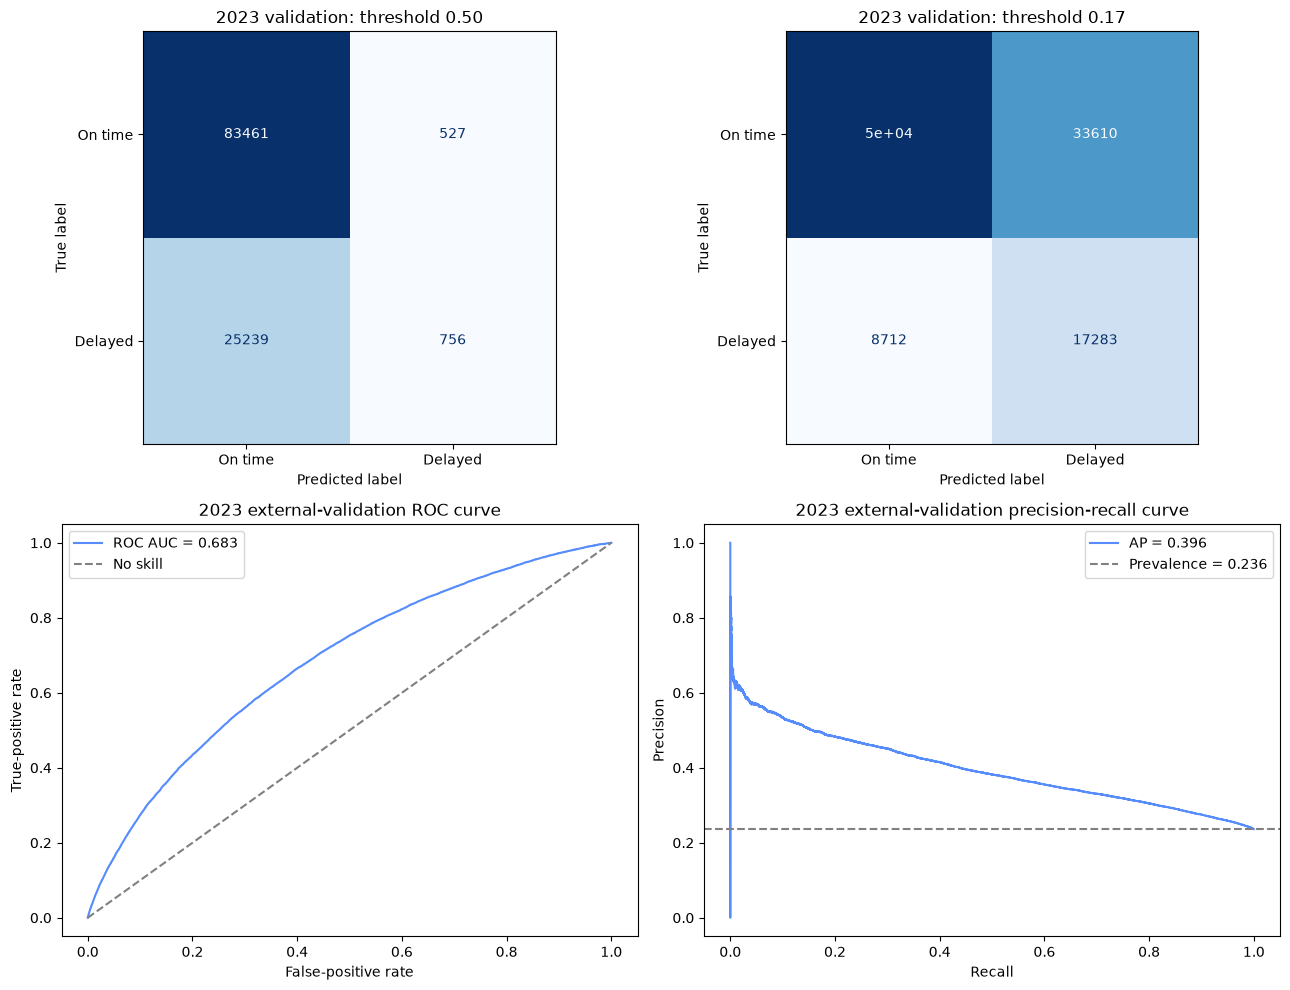

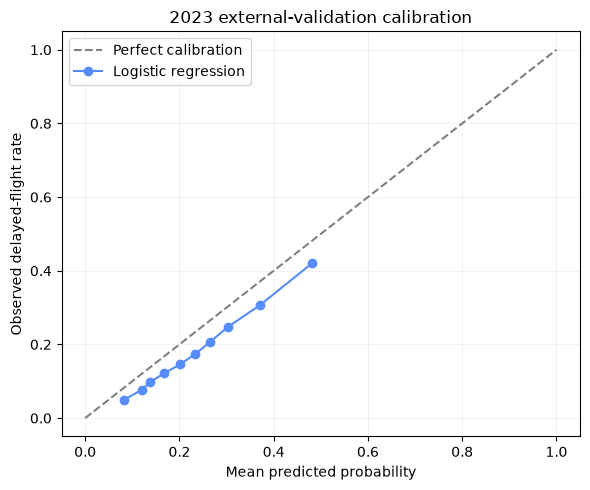

In [14]:
default_predictions = (validation_probabilities >= 0.50).astype(int)
selected_predictions = (validation_probabilities >= selected_threshold).astype(int)

false_positive_rate, true_positive_rate, _ = roc_curve(y_validation, validation_probabilities)
curve_precision, curve_recall, _ = precision_recall_curve(y_validation, validation_probabilities)
calibration_predicted, calibration_observed = calibration_curve(
    y_validation,
    validation_probabilities,
    n_bins=10,
    strategy="quantile",
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    default_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("2023 validation: threshold 0.50")

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    selected_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title(f"2023 validation: threshold {selected_threshold:.2f}")

axes[1, 0].plot(
    false_positive_rate,
    true_positive_rate,
    label=f"ROC AUC = {roc_auc_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="No skill")
axes[1, 0].set(
    xlabel="False-positive rate",
    ylabel="True-positive rate",
    title="2023 external-validation ROC curve",
)
axes[1, 0].legend()

axes[1, 1].plot(
    curve_recall,
    curve_precision,
    label=f"AP = {average_precision_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 1].axhline(
    y_validation.mean(),
    linestyle="--",
    color="gray",
    label=f"Prevalence = {y_validation.mean():.3f}",
)
axes[1, 1].set(
    xlabel="Recall",
    ylabel="Precision",
    title="2023 external-validation precision-recall curve",
)
axes[1, 1].legend()

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(
    calibration_predicted,
    calibration_observed,
    marker="o",
    label="Logistic regression",
)
ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed delayed-flight rate",
    title="2023 external-validation calibration",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Inspect retained coefficients

Coefficient magnitude is comparable only within this encoded and standardized design matrix. Positive coefficients are associated with greater predicted delay odds and negative coefficients with lower predicted delay odds. They do not establish causal effects.

In [15]:
classifier = best_logistic_pipeline.named_steps["classifier"]
coefficient_series = pd.Series(
    classifier.coef_[0],
    index=selected_feature_names,
    name="coefficient",
)

coefficient_table = (
    coefficient_series.rename_axis("feature")
    .reset_index()
    .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)

display(coefficient_table.head(20))

most_positive = coefficient_series.nlargest(10)
most_negative = coefficient_series.nsmallest(10)

coefficient_summary = pd.DataFrame(
    {
        "most_positive_feature": most_positive.index,
        "positive_coefficient": most_positive.values,
        "most_negative_feature": most_negative.index,
        "negative_coefficient": most_negative.values,
    }
)
coefficient_summary


,feature,coefficient,abs_coefficient
45,categorical__Dest_HNL,1.9209,1.9209
24,categorical__Reporting_Airline_HA,-1.6425,1.6425
77,categorical__Dest_SNA,-1.4015,1.4015
10,categorical__Month_11,-1.0352,1.0352
26,categorical__Reporting_Airline_OH,-0.8765,0.8765
2,categorical__Month_3,-0.7914,0.7914
13,categorical__DayOfWeek_2,-0.7796,0.7796
18,categorical__DayOfWeek_7,-0.7762,0.7762
9,categorical__Month_10,-0.7761,0.7761
12,categorical__DayOfWeek_1,-0.7307,0.7307


,most_positive_feature,positive_coefficient,most_negative_feature,negative_coefficient
0,categorical__Dest_HNL,1.9209,categorical__Reporting_Airline_HA,-1.6425
1,categorical__Dest_IAH,0.5417,categorical__Dest_SNA,-1.4015
2,categorical__Month_8,0.4684,categorical__Month_11,-1.0352
3,categorical__Month_7,0.4333,categorical__Reporting_Airline_OH,-0.8765
4,numeric__CRSDepTime,0.4266,categorical__Month_3,-0.7914
5,categorical__Dest_DFW,0.4173,categorical__DayOfWeek_2,-0.7796
6,categorical__Dest_ORD,0.3833,categorical__DayOfWeek_7,-0.7762
7,numeric__HourlyRelativeHumidity,0.3127,categorical__Month_10,-0.7761
8,categorical__Dest_BOS,0.2611,categorical__DayOfWeek_1,-0.7307
9,categorical__Dest_HOU,0.2480,categorical__DayOfWeek_3,-0.7164


## Experiment 01 interpretation checklist

Use the displayed results to answer these questions before moving to Experiment 02:

1. Did the best expanding-window configuration beat delayed-flight prevalence by a meaningful margin in average precision?
2. Did performance persist when the all-2019 fit was applied to 2023?
3. Did `SelectFromModel` win, and if so, was its improvement large enough to justify removing encoded columns?
4. How much recall was gained—and how much precision was lost—at the training-selected threshold?
5. Are predicted probabilities reasonably calibrated?
6. Do the largest coefficients reflect plausible schedule, route, traffic, and weather associations?

Treat 2023 as an external development/validation year: its results may motivate a new, separately numbered experiment, but must not be used to refit or tune this Experiment 01 result. Experiment 02 should keep the same population, 2019 folds, 2023 validation year, metrics, and raw-feature reference while testing the compact engineered feature manifest. The 2024 dataset remains locked for final evaluation.